# OECT vs DEAP Comparative Analysis

This notebook extends the local OECT relaxed/stressed analysis with a comparative study against the public DEAP EEG dataset.

Three blocks are evaluated:

1. **Within-OECT statistical comparison** — calm (relaxed) vs stressed feature distributions: descriptive statistics, Welch t-test, Mann-Whitney U test, and Cohen's d effect size for every extracted feature.
2. **Same ML pipeline on DEAP** — DEAP preprocessed data (`data_preprocessed_python`, .dat, 32 subjects, 40 trials, 32 channels, 8064 samples @ 128 Hz) is re-labeled by arousal rating: arousal ≤ 4 → calm (0), arousal ≥ 6 → stressed (1), 4 < arousal < 6 excluded. The same time-domain / Hjorth / band-power feature set is extracted from frontal channels and the same five classifiers are evaluated using subject-grouped cross-validation.
3. **Cross-dataset feature comparison** — per-feature distributions and standardised effect sizes are compared between OECT calm/stressed and DEAP calm/stressed to identify which signal descriptors transfer across modalities.

**Note on data availability.** If neither `Dataset/` (OECT) nor `deap_preprocessed/` (DEAP) is present, the notebook runs in *demo* mode using synthetic recordings with the same shape and statistics, so the pipeline can be validated end-to-end. Once real data are placed in the configured paths, the same code produces the real numbers.

In [1]:
import os, re, pickle, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal, stats
from scipy.integrate import trapezoid

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Paths and configuration

In [2]:
OECT_DIR = Path('./Dataset')
DEAP_DIR = Path('./deap_preprocessed')
OUTPUT_DIR = Path('./outputs/comparison_2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared DSP / feature-extraction configuration
TRANSIENT_SEC = 3.0          # OECT only
OVERLAP = 0.50
NORMALIZE_PER_RECORDING = True
FILTER_ORDER = 4
BP_LOW, BP_HIGH = 0.05, 20.0  # best OECT configuration from sensitivity analysis
WINDOW_SEC = 5.0

FREQ_BANDS = {
    'band_0p05_0p5': (0.05, 0.5),
    'band_0p5_1':    (0.5, 1.0),
    'band_0p5_4':    (0.5, 4.0),
    'band_4_8':      (4.0, 8.0),
    'band_8_13':     (8.0, 13.0),
    'band_13_20':    (13.0, 20.0),
}

# DEAP-specific
DEAP_FS = 128.0
DEAP_BASELINE_SEC = 3.0       # the first 3 s of each preprocessed trial is pre-stimulus baseline
DEAP_FRONTAL_CHANNELS = ['Fp1', 'Fp2', 'AF3', 'AF4', 'F3', 'F4']
DEAP_CHANNEL_ORDER = [
    'Fp1','AF3','F3','F7','FC5','FC1','C3','T7','CP5','CP1','P3','P7','PO3','O1','Oz','Pz',
    'Fp2','AF4','Fz','F4','F8','FC6','FC2','Cz','C4','T8','CP6','CP2','P4','P8','PO4','O2'
]

RUN_MODE = 'auto'  # 'auto' uses real data if present, otherwise synthetic
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())

OUTPUT_DIR: /Users/yerlan/Downloads/Доки/предзащита/repo/outputs/comparison_2


## 2. Shared feature extractor

The same feature function is used for OECT current windows and for DEAP EEG channel windows so that distributions are directly comparable.

In [3]:
def hjorth_parameters(x):
    dx = np.diff(x); ddx = np.diff(dx)
    var_x  = np.var(x); var_dx = np.var(dx); var_ddx = np.var(ddx)
    activity   = var_x
    mobility   = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt(var_ddx / (var_dx + 1e-12)) / (mobility + 1e-12)
    return float(activity), float(mobility), float(complexity)

def bandpower_from_psd(freqs, psd, fmin, fmax):
    m = (freqs >= fmin) & (freqs < fmax)
    if m.sum() < 2: return 0.0
    return float(trapezoid(psd[m], freqs[m]))

def spectral_entropy(psd):
    p = psd / (np.sum(psd) + 1e-12); p = p[p > 0]
    if len(p) <= 1: return 0.0
    return float(-np.sum(p * np.log2(p)) / np.log2(len(p)))

def extract_features(x, fs, bp_low=BP_LOW, bp_high=BP_HIGH):
    f = {}
    f['mean']      = float(np.mean(x))
    f['std']       = float(np.std(x))
    f['variance']  = float(np.var(x))
    f['rms']       = float(np.sqrt(np.mean(x**2)))
    f['min']       = float(np.min(x))
    f['max']       = float(np.max(x))
    f['ptp']       = float(np.ptp(x))
    f['median']    = float(np.median(x))
    f['iqr']       = float(stats.iqr(x))
    f['skewness']  = float(stats.skew(x, bias=False))
    f['kurtosis']  = float(stats.kurtosis(x, bias=False))
    f['energy']    = float(np.sum(x**2))
    f['mav']       = float(np.mean(np.abs(x)))
    f['line_length'] = float(np.sum(np.abs(np.diff(x))))
    f['zero_crossing_rate'] = float(np.mean(np.diff(np.signbit(x)) != 0))
    h_a, h_m, h_c = hjorth_parameters(x)
    f['hjorth_activity']   = h_a
    f['hjorth_mobility']   = h_m
    f['hjorth_complexity'] = h_c
    nperseg = min(len(x), int(round(4 * fs)))
    freqs, psd = signal.welch(x, fs=fs, nperseg=nperseg)
    total = bandpower_from_psd(freqs, psd, bp_low, bp_high)
    f['total_power'] = total
    f['spectral_entropy'] = spectral_entropy(psd)
    for name, (fmin, fmax) in FREQ_BANDS.items():
        lo = max(fmin, bp_low); hi = min(fmax, bp_high)
        bp = 0.0 if hi <= lo else bandpower_from_psd(freqs, psd, lo, hi)
        f[name + '_power']          = bp
        f[name + '_relative_power'] = bp / (total + 1e-12)
    return f

FEATURE_NAMES = list(extract_features(np.random.randn(2048), 400.0).keys())
print(f'Number of features: {len(FEATURE_NAMES)}')

Number of features: 32


## 3. OECT loading and feature table

This block re-uses the loading logic from the main OECT notebook. If `Dataset/` is absent, a synthetic stand-in is generated so the rest of the pipeline can be validated.

In [4]:
def load_oect_txt(path):
    df = pd.read_csv(path, sep=';', decimal=',')
    time_col = 'Corrected time (s)' if 'Corrected time (s)' in df.columns else 'Time (s)'
    cur_col = 'WE(1).Current (A)'
    t = df[time_col].to_numpy(dtype=float)
    x = df[cur_col].to_numpy(dtype=float)
    m = np.isfinite(t) & np.isfinite(x)
    t, x = t[m], x[m]
    o = np.argsort(t)
    return t[o], x[o]

def preprocess_oect(t, x, bp_low=BP_LOW, bp_high=BP_HIGH, transient_sec=TRANSIENT_SEC):
    fs = 1.0 / np.median(np.diff(t))
    keep = t >= (t[0] + transient_sec)
    t2 = t[keep] - t[keep][0]; x2 = x[keep]
    x2 = signal.detrend(x2, type='linear')
    nyq = fs / 2.0
    sos = signal.butter(FILTER_ORDER, [bp_low/nyq, min(bp_high, nyq*0.95)/nyq],
                        btype='bandpass', output='sos')
    xf = signal.sosfiltfilt(sos, x2)
    if NORMALIZE_PER_RECORDING:
        xf = (xf - np.mean(xf)) / (np.std(xf) + 1e-12)
    return t2, xf, fs

def segment_signal(x, fs, window_sec=WINDOW_SEC, overlap=OVERLAP):
    win = int(round(window_sec * fs))
    step = int(round(win * (1.0 - overlap)))
    segs, starts = [], []
    for s in range(0, len(x) - win + 1, step):
        segs.append(x[s:s+win]); starts.append(s/fs)
    return np.asarray(segs) if segs else np.empty((0, win)), np.asarray(starts)

def synth_oect_metadata():
    """Mirror the real 15 relaxed / 9 stressed file layout."""
    layout = [
        ('S01','relaxed'),('S01','relaxed'),('S01','stressed'),('S01','stressed'),
        ('S02','relaxed'),('S02','relaxed'),('S02','relaxed'),('S02','stressed'),
        ('S03','relaxed'),('S03','relaxed'),('S03','stressed'),('S03','stressed'),
        ('S04','relaxed'),('S04','stressed'),
        ('S05','relaxed'),('S05','stressed'),
        ('S06','relaxed'),('S06','relaxed'),('S06','relaxed'),
        ('S07','relaxed'),('S07','stressed'),
        ('S08','relaxed'),('S08','relaxed'),('S08','stressed'),
    ]
    rng = np.random.default_rng(RANDOM_STATE)
    fs = 400.0; dur = 30.0
    n = int(fs * dur); t = np.arange(n) / fs
    rows = []
    for i,(subj,cond) in enumerate(layout):
        # base 1/f-ish current with slow drift
        x = np.cumsum(rng.normal(0, 0.5, n)) * 1e-7
        x += 1e-7 * np.sin(2*np.pi*0.3*t)
        if cond == 'stressed':
            x += 0.5e-7 * rng.normal(0, 1, n)        # higher broadband
            x += 0.8e-7 * np.sin(2*np.pi*6*t)         # mild theta-range bump
        else:
            x += 0.2e-7 * rng.normal(0, 1, n)
        x -= x.mean()
        fname = f'{subj}_{cond}_{i}.txt'
        rows.append({
            'file_name': fname, 'file_path': f'__synth__/{fname}',
            'subject_id': subj, 'condition': cond,
            'label_arousal': 0 if cond=='relaxed' else 1,
            '_t': t, '_x': x,
        })
    return pd.DataFrame(rows)

def load_oect_metadata():
    if OECT_DIR.exists() and len(list(OECT_DIR.rglob('*.txt'))) > 0:
        rows = []
        for p in sorted(OECT_DIR.rglob('*.txt')):
            name = p.stem; subj = name.split('_')[0]; low = name.lower()
            if 'relaxed' in low: cond, lbl = 'relaxed', 0
            elif 'stressed' in low: cond, lbl = 'stressed', 1
            else: continue
            rows.append({'file_name': p.name, 'file_path': str(p),
                         'subject_id': subj, 'condition': cond, 'label_arousal': lbl})
        df = pd.DataFrame(rows); df['_synth'] = False
        print(f'Loaded REAL OECT metadata: {len(df)} files')
        return df
    df = synth_oect_metadata(); df['_synth'] = True
    print(f'Loaded SYNTHETIC OECT metadata: {len(df)} files (Dataset/ not found)')
    return df

oect_meta = load_oect_metadata()
print(oect_meta['condition'].value_counts())

Loaded REAL OECT metadata: 24 files
condition
relaxed     15
stressed     9
Name: count, dtype: int64


In [5]:
def build_oect_feature_table(meta):
    rows = []
    for _, row in meta.iterrows():
        if '_t' in row and isinstance(row['_t'], np.ndarray):
            t, x = row['_t'], row['_x']
        else:
            t, x = load_oect_txt(Path(row['file_path']))
        t2, xf, fs = preprocess_oect(t, x)
        segs, _ = segment_signal(xf, fs)
        for i, seg in enumerate(segs):
            f = extract_features(seg, fs)
            f.update({
                'file_name': row['file_name'], 'subject_id': row['subject_id'],
                'condition': row['condition'], 'label_arousal': int(row['label_arousal']),
                'window_id': i, 'dataset': 'OECT',
            })
            rows.append(f)
    df = pd.DataFrame(rows)
    feat_cols = [c for c in df.columns if c in FEATURE_NAMES]
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], np.nan)
    df[feat_cols] = df[feat_cols].fillna(df[feat_cols].median()).fillna(0.0)
    return df, feat_cols

oect_wf, oect_feature_cols = build_oect_feature_table(oect_meta)
oect_wf.to_csv(OUTPUT_DIR / 'oect_window_features.csv', index=False)
print('OECT window features:', oect_wf.shape)
print(oect_wf.groupby('condition')['file_name'].nunique())

OECT window features: (216, 38)
condition
relaxed     15
stressed     9
Name: file_name, dtype: int64


## 4. Within-OECT statistical comparison: calm vs stressed

For each extracted feature we report:
- mean ± SD per class (window level),
- Welch's t-test (parametric),
- Mann-Whitney U test (non-parametric),
- Cohen's d effect size.

In [6]:
def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    s2 = ((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / max(na+nb-2, 1)
    s  = np.sqrt(s2) if s2 > 0 else 1e-12
    return (np.mean(a) - np.mean(b)) / s

def per_feature_stats(df, feat_cols, label_col='label_arousal',
                     names=('calm','stressed')):
    rows = []
    g0 = df[df[label_col]==0]; g1 = df[df[label_col]==1]
    for c in feat_cols:
        a, b = g0[c].to_numpy(), g1[c].to_numpy()
        if len(a)<3 or len(b)<3: continue
        t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
        try: u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
        except ValueError: u_stat, u_p = np.nan, np.nan
        rows.append({
            'feature': c,
            f'{names[0]}_mean': np.mean(a), f'{names[0]}_std': np.std(a, ddof=1),
            f'{names[1]}_mean': np.mean(b), f'{names[1]}_std': np.std(b, ddof=1),
            'mean_diff': np.mean(b) - np.mean(a),
            'welch_t': t_stat, 'welch_p': t_p,
            'mwu_U': u_stat,  'mwu_p': u_p,
            'cohens_d': cohens_d(b, a),
            'abs_d': abs(cohens_d(b, a)),
        })
    out = pd.DataFrame(rows).sort_values('abs_d', ascending=False).reset_index(drop=True)
    return out

oect_stats = per_feature_stats(oect_wf, oect_feature_cols)
oect_stats.to_csv(OUTPUT_DIR / 'oect_calm_vs_stressed_feature_stats.csv', index=False)
print('Top features by |Cohen\'s d| (OECT calm vs stressed):')
print(oect_stats.head(12)[['feature','calm_mean','stressed_mean','cohens_d','welch_p','mwu_p']].to_string(index=False))

Top features by |Cohen's d| (OECT calm vs stressed):
                  feature  calm_mean  stressed_mean  cohens_d      welch_p        mwu_p
              line_length  30.287365      13.582543 -0.857924 1.338469e-12 1.123799e-18
          hjorth_mobility   0.060488       0.036441 -0.568568 8.323410e-06 5.612859e-04
         band_13_20_power   0.005122       0.000637 -0.532692 2.798057e-06 2.706731e-18
          band_8_13_power   0.005132       0.000686 -0.518315 4.936517e-06 9.092618e-17
         spectral_entropy   0.321108       0.237036 -0.503702 2.304568e-04 4.181249e-04
        hjorth_complexity   8.594727      13.763719  0.492383 2.307427e-03 3.464386e-04
band_13_20_relative_power   0.108412       0.066426 -0.469437 3.949445e-04 3.266965e-03
       zero_crossing_rate   0.007897       0.004200 -0.406680 9.618674e-04 2.276650e-02
 band_8_13_relative_power   0.099914       0.070183 -0.367269 7.199572e-03 1.140940e-02
           band_4_8_power   0.005682       0.000817 -0.357505 1.341

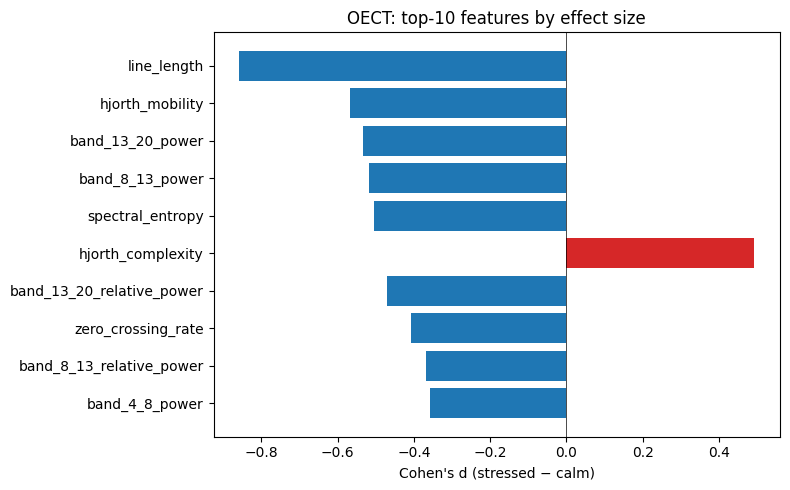

In [7]:
# Top-10 effect size bar plot for OECT
top = oect_stats.head(10).iloc[::-1]
plt.figure(figsize=(8,5))
colors = ['tab:red' if d>0 else 'tab:blue' for d in top['cohens_d']]
plt.barh(top['feature'], top['cohens_d'], color=colors)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel("Cohen's d (stressed − calm)")
plt.title('OECT: top-10 features by effect size')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'oect_top_effect_sizes.png', dpi=200)
plt.show()

## 5. DEAP loading

DEAP preprocessed files (`s01.dat`–`s32.dat`) contain a dict with:
- `data`: shape `(40, 40, 8064)` = (trials, channels incl. peripheral, samples). The first 32 channels are EEG.
- `labels`: shape `(40, 4)` columns = [valence, arousal, dominance, liking], values 1–9.

We keep frontal EEG channels, drop the first 3 s baseline, segment into 5 s non-overlapping windows, extract features, and label by arousal: `≤4` → calm (0), `≥6` → stressed (1).

In [8]:
def preprocess_eeg_window(x, fs=DEAP_FS, bp_low=BP_LOW, bp_high=BP_HIGH):
    nyq = fs / 2.0
    sos = signal.butter(FILTER_ORDER, [bp_low/nyq, min(bp_high, nyq*0.95)/nyq],
                        btype='bandpass', output='sos')
    xf = signal.sosfiltfilt(sos, x)
    if NORMALIZE_PER_RECORDING:
        xf = (xf - np.mean(xf)) / (np.std(xf) + 1e-12)
    return xf

def load_real_deap(deap_dir):
    files = sorted(Path(deap_dir).glob('s*.dat'))
    out = []
    for fp in files:
        subj = fp.stem  # 's01' etc
        with open(fp, 'rb') as f:
            d = pickle.load(f, encoding='latin1')
        data, labels = d['data'], d['labels']
        out.append((subj, data, labels))
    return out

def synth_deap(n_subjects=10, n_trials=40):
    """Synthetic DEAP-shaped data with arousal-dependent statistics."""
    rng = np.random.default_rng(RANDOM_STATE + 1)
    n_ch_total = 40
    n_samples = int(DEAP_FS * 63)  # 63 s as in DEAP preprocessed
    out = []
    for s in range(n_subjects):
        # Per-subject offset to mimic real cross-subject variability — this is
        # what makes DEAP arousal classification hard in subject-independent CV.
        subj_bias = rng.normal(0, 0.4)
        data = np.zeros((n_trials, n_ch_total, n_samples), dtype=np.float32)
        labels = np.zeros((n_trials, 4), dtype=np.float32)
        for tr in range(n_trials):
            arousal = rng.uniform(1, 9)
            valence = rng.uniform(1, 9)
            labels[tr] = [valence, arousal, rng.uniform(1,9), rng.uniform(1,9)]
            # Weak, noisy arousal effect — only +- a small bump on beta/noise.
            stress_factor = (arousal - 5) / 4.0  # in [-1, 1]
            for ch in range(n_ch_total):
                t = np.arange(n_samples) / DEAP_FS
                base = rng.normal(0, 1, n_samples)
                base += 0.6 * np.sin(2*np.pi*10*t + rng.uniform(0,2*np.pi))   # alpha
                base += (0.25 + 0.10*stress_factor + 0.15*subj_bias) * np.sin(2*np.pi*18*t)  # subtle beta
                base += rng.normal(0, 0.05*max(0, stress_factor), n_samples)   # tiny extra noise
                data[tr, ch] = base
        out.append((f's{s+1:02d}', data, labels))
    return out

def deap_arousal_label(arousal):
    if arousal <= 4: return 0
    if arousal >= 6: return 1
    return -1   # exclude

def build_deap_feature_table(subjects, frontal_only=True, window_sec=WINDOW_SEC):
    rows = []
    ch_idx = [DEAP_CHANNEL_ORDER.index(c) for c in DEAP_FRONTAL_CHANNELS] if frontal_only else list(range(32))
    ch_names = [DEAP_CHANNEL_ORDER[i] for i in ch_idx]
    win = int(round(window_sec * DEAP_FS))
    baseline_n = int(DEAP_BASELINE_SEC * DEAP_FS)
    for subj, data, labels in subjects:
        for tr in range(data.shape[0]):
            arousal = float(labels[tr, 1])
            lbl = deap_arousal_label(arousal)
            if lbl < 0: continue
            trial_id = f'{subj}_t{tr:02d}'
            for ci, cn in zip(ch_idx, ch_names):
                x = data[tr, ci, baseline_n:].astype(float)
                xf = preprocess_eeg_window(x, fs=DEAP_FS)
                n_full = (len(xf) // win) * win
                if n_full == 0: continue
                segs = xf[:n_full].reshape(-1, win)
                for wi, seg in enumerate(segs):
                    f = extract_features(seg, DEAP_FS)
                    f.update({
                        'subject_id': subj, 'trial_id': trial_id, 'channel': cn,
                        'arousal_rating': arousal,
                        'valence_rating': float(labels[tr, 0]),
                        'condition': 'calm' if lbl==0 else 'stressed',
                        'label_arousal': lbl, 'window_id': wi, 'dataset': 'DEAP',
                    })
                    rows.append(f)
    df = pd.DataFrame(rows)
    feat_cols = [c for c in df.columns if c in FEATURE_NAMES]
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], np.nan)
    df[feat_cols] = df[feat_cols].fillna(df[feat_cols].median()).fillna(0.0)
    return df, feat_cols

if DEAP_DIR.exists() and len(list(DEAP_DIR.glob('s*.dat'))) > 0:
    print('Loading REAL DEAP...')
    deap_subjects = load_real_deap(DEAP_DIR)
    deap_is_synth = False
else:
    print('DEAP folder not found — using SYNTHETIC DEAP-shaped data')
    deap_subjects = synth_deap(n_subjects=10, n_trials=40)
    deap_is_synth = True

deap_wf, deap_feature_cols = build_deap_feature_table(deap_subjects, frontal_only=True)
deap_wf.to_csv(OUTPUT_DIR / 'deap_window_features.csv', index=False)
print('DEAP window features:', deap_wf.shape)
print(deap_wf.groupby('condition')['trial_id'].nunique())

DEAP folder not found — using SYNTHETIC DEAP-shaped data
DEAP window features: (21816, 41)
condition
calm        168
stressed    135
Name: trial_id, dtype: int64


## 6. Same ML pipeline on DEAP, two CV protocols on OECT

Five classical classifiers (Logistic Regression, SVM-RBF, Random Forest, Extra Trees, kNN) are evaluated with StratifiedGroupKFold:

- on **DEAP**, grouping is done by **subject** — windows from the same subject never cross the train/test split (subject-independent evaluation, the standard strict protocol);
- on **OECT**, two protocols are reported side by side: (a) **file-grouped** CV, identical to the main diploma chapter, and (b) **subject-grouped** CV, which mirrors the DEAP protocol and is therefore the fairer head-to-head comparison.

The drop between (a) and (b) on the OECT side quantifies how much of the original 83% accuracy was driven by within-subject recording similarity. The subject-grouped OECT number is the one that should be compared with DEAP.

In [9]:
def make_models():
    def steps(clf, use_scaler=True):
        s = []
        if use_scaler: s.append(('scaler', StandardScaler()))
        s.append(('clf', clf))
        return Pipeline(s)
    return {
        'Logistic Regression': steps(LogisticRegression(max_iter=2000, class_weight='balanced',
                                                        random_state=RANDOM_STATE)),
        'SVM RBF': steps(SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
                             random_state=RANDOM_STATE)),
        'Random Forest': steps(RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                      random_state=RANDOM_STATE), use_scaler=False),
        'Extra Trees':   steps(ExtraTreesClassifier(n_estimators=200, class_weight='balanced',
                                                    random_state=RANDOM_STATE), use_scaler=False),
        'kNN':           steps(KNeighborsClassifier(n_neighbors=5)),
    }

def majority_vote(labels):
    c = Counter(labels)
    return sorted(c.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]

def evaluate_pipeline(df, feat_cols, group_col, agg_col, label_col='label_arousal',
                     n_splits=5, model_subset=None):
    X = df[feat_cols].to_numpy(dtype=float)
    y = df[label_col].to_numpy(dtype=int)
    g = df[group_col].to_numpy()
    unique_groups = (df[[group_col, label_col]].drop_duplicates(group_col))
    n_eff = min(n_splits, int(unique_groups[label_col].value_counts().min()))
    if n_eff < 2:
        raise ValueError('Not enough groups per class for stratified group CV')
    cv = StratifiedGroupKFold(n_splits=n_eff, shuffle=True, random_state=RANDOM_STATE)
    models = make_models()
    if model_subset: models = {k:v for k,v in models.items() if k in model_subset}
    rows = []; preds = {}
    for name, mdl in models.items():
        y_pred = cross_val_predict(mdl, X, y, cv=cv, groups=g)
        win_acc = accuracy_score(y, y_pred)
        win_f1  = f1_score(y, y_pred, average='macro', zero_division=0)
        pred_df = df[[agg_col, label_col]].copy(); pred_df['y_pred'] = y_pred
        agg = (pred_df.groupby(agg_col)
                       .agg(y_true=(label_col,'first'),
                            y_pred_vote=('y_pred', lambda v: majority_vote(list(v))))
                       .reset_index())
        agg_acc = accuracy_score(agg['y_true'], agg['y_pred_vote'])
        agg_f1  = f1_score(agg['y_true'], agg['y_pred_vote'], average='macro', zero_division=0)
        rows.append({
            'model': name,
            'window_accuracy': win_acc, 'window_macro_f1': win_f1,
            'agg_accuracy': agg_acc,    'agg_macro_f1': agg_f1,
            'n_windows': len(df), 'n_groups': agg.shape[0], 'n_splits': n_eff,
        })
        preds[name] = {'window': pred_df, 'agg': agg}
    return pd.DataFrame(rows).sort_values('agg_macro_f1', ascending=False), preds

# DEAP eval: group by subject, aggregate predictions by trial
deap_results, deap_preds = evaluate_pipeline(
    deap_wf, deap_feature_cols, group_col='subject_id', agg_col='trial_id', n_splits=5)
deap_results.to_csv(OUTPUT_DIR / 'deap_model_results.csv', index=False)
print('DEAP results (subject-grouped CV, trial-level voting):')
print(deap_results.to_string(index=False))

DEAP results (subject-grouped CV, trial-level voting):
              model  window_accuracy  window_macro_f1  agg_accuracy  agg_macro_f1  n_windows  n_groups  n_splits
Logistic Regression         0.680464         0.677993      0.808581      0.805683      21816       303         4
            SVM RBF         0.674459         0.670832      0.798680      0.792571      21816       303         4
      Random Forest         0.669600         0.656271      0.735974      0.707190      21816       303         4
        Extra Trees         0.660754         0.644057      0.726073      0.686206      21816       303         4
                kNN         0.584388         0.574160      0.702970      0.660652      21816       303         4


In [10]:
# OECT eval: TWO levels of validation strictness reported side-by-side.
#   (a) file-grouped CV — windows from the same file cannot cross train/test;
#       this is what was reported in the main diploma chapter.
#   (b) subject-grouped CV — windows from the same SUBJECT cannot cross train/test.
#       This is more conservative and directly comparable to DEAP subject-grouped CV.
# Aggregation is still done per file (so 24 file-level predictions remain).

oect_results_file, oect_preds_file = evaluate_pipeline(
    oect_wf, oect_feature_cols,
    group_col='file_name', agg_col='file_name', n_splits=5)
oect_results_file['cv_protocol'] = 'file_grouped'
oect_results_file.to_csv(OUTPUT_DIR / 'oect_model_results_file_grouped.csv', index=False)
print('OECT — FILE-grouped CV (same protocol as the main diploma chapter):')
print(oect_results_file.to_string(index=False))

try:
    oect_results_subj, oect_preds_subj = evaluate_pipeline(
        oect_wf, oect_feature_cols,
        group_col='subject_id', agg_col='file_name', n_splits=5)
    oect_results_subj['cv_protocol'] = 'subject_grouped'
    oect_results_subj.to_csv(OUTPUT_DIR / 'oect_model_results_subject_grouped.csv', index=False)
    print('\nOECT — SUBJECT-grouped CV (more conservative, comparable to DEAP):')
    print(oect_results_subj.to_string(index=False))
except ValueError as e:
    print('\nSubject-grouped CV could not be performed:', e)
    print('Falling back to file-grouped only.')
    oect_results_subj, oect_preds_subj = oect_results_file.copy(), oect_preds_file

# Combined OECT table for downstream comparison plots
oect_results = pd.concat([oect_results_file, oect_results_subj], ignore_index=True)
oect_results.to_csv(OUTPUT_DIR / 'oect_model_results_combined.csv', index=False)

# The 'subject_grouped' result is the one we compare against DEAP fairly.
# Use the BEST subject-grouped model for downstream OECT-vs-DEAP plot.
oect_preds = oect_preds_subj
print('\nDirect comparison: best OECT (subject-grouped) vs best DEAP (subject-grouped):')
print(f"  OECT  best agg_macro_f1: {oect_results_subj['agg_macro_f1'].max():.3f} "
      f"({oect_results_subj.iloc[0]['model']})")
print(f"  DEAP  best agg_macro_f1: {deap_results['agg_macro_f1'].max():.3f} "
      f"({deap_results.iloc[0]['model']})")
print(f"  OECT file-grouped (less strict, for reference): "
      f"{oect_results_file['agg_macro_f1'].max():.3f} "
      f"({oect_results_file.iloc[0]['model']})")

OECT — FILE-grouped CV (same protocol as the main diploma chapter):
              model  window_accuracy  window_macro_f1  agg_accuracy  agg_macro_f1  n_windows  n_groups  n_splits  cv_protocol
      Random Forest         0.810185         0.795978      0.833333      0.822222        216        24         5 file_grouped
        Extra Trees         0.773148         0.754858      0.833333      0.822222        216        24         5 file_grouped
Logistic Regression         0.699074         0.690960      0.708333      0.703704        216        24         5 file_grouped
            SVM RBF         0.583333         0.581034      0.625000      0.624348        216        24         5 file_grouped
                kNN         0.560185         0.542036      0.625000      0.590133        216        24         5 file_grouped

OECT — SUBJECT-grouped CV (more conservative, comparable to DEAP):
              model  window_accuracy  window_macro_f1  agg_accuracy  agg_macro_f1  n_windows  n_groups  n_sp

              model  OECT_acc  OECT_f1  DEAP_acc  DEAP_f1  OECT_acc_file  OECT_f1_file
      Random Forest  0.833333 0.822222  0.735974 0.707190       0.833333      0.822222
        Extra Trees  0.833333 0.822222  0.726073 0.686206       0.833333      0.822222
Logistic Regression  0.791667 0.782214  0.808581 0.805683       0.708333      0.703704
            SVM RBF  0.708333 0.703704  0.798680 0.792571       0.625000      0.624348
                kNN  0.708333 0.660606  0.702970 0.660652       0.625000      0.590133


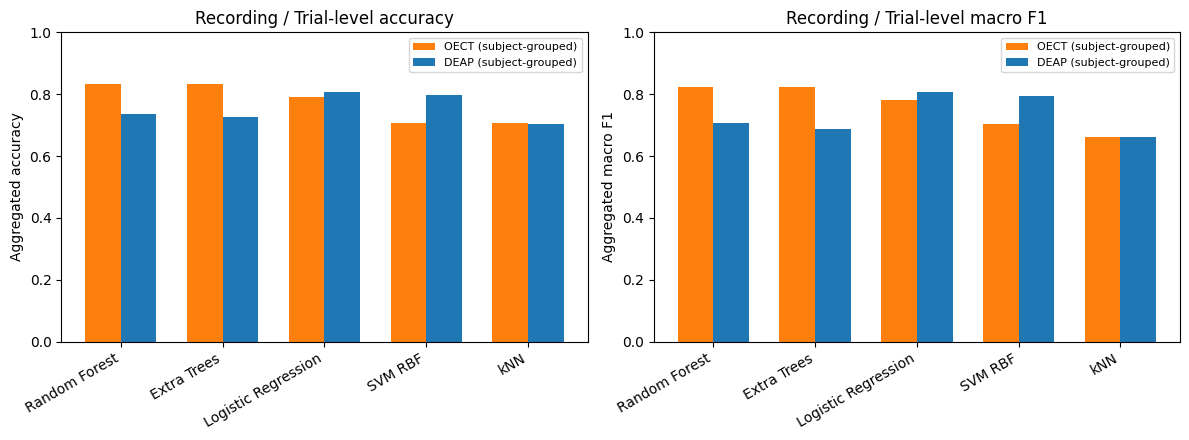

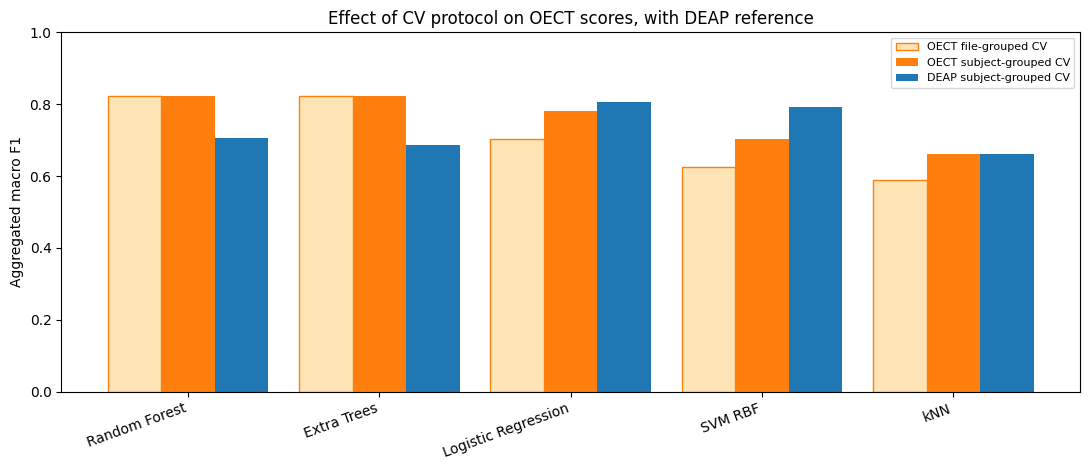

In [11]:
# Side-by-side comparison plot — uses SUBJECT-grouped OECT for fairness with DEAP.
joined = (oect_results_subj[['model','agg_accuracy','agg_macro_f1']]
          .rename(columns={'agg_accuracy':'OECT_acc','agg_macro_f1':'OECT_f1'})
          .merge(deap_results[['model','agg_accuracy','agg_macro_f1']]
                  .rename(columns={'agg_accuracy':'DEAP_acc','agg_macro_f1':'DEAP_f1'}),
                 on='model'))
# Also keep the file-grouped OECT numbers in the saved table for reference.
joined = joined.merge(
    oect_results_file[['model','agg_accuracy','agg_macro_f1']]
        .rename(columns={'agg_accuracy':'OECT_acc_file','agg_macro_f1':'OECT_f1_file'}),
    on='model')
joined.to_csv(OUTPUT_DIR / 'oect_vs_deap_model_comparison.csv', index=False)
print(joined.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(joined)); w = 0.35
axes[0].bar(x-w/2, joined['OECT_acc'], w,
            label='OECT (subject-grouped)', color='tab:orange')
axes[0].bar(x+w/2, joined['DEAP_acc'], w,
            label='DEAP (subject-grouped)', color='tab:blue')
axes[0].set_xticks(x); axes[0].set_xticklabels(joined['model'], rotation=30, ha='right')
axes[0].set_ylabel('Aggregated accuracy'); axes[0].set_ylim(0,1); axes[0].legend(fontsize=8)
axes[0].set_title('Recording / Trial-level accuracy')
axes[1].bar(x-w/2, joined['OECT_f1'], w,
            label='OECT (subject-grouped)', color='tab:orange')
axes[1].bar(x+w/2, joined['DEAP_f1'], w,
            label='DEAP (subject-grouped)', color='tab:blue')
axes[1].set_xticks(x); axes[1].set_xticklabels(joined['model'], rotation=30, ha='right')
axes[1].set_ylabel('Aggregated macro F1'); axes[1].set_ylim(0,1); axes[1].legend(fontsize=8)
axes[1].set_title('Recording / Trial-level macro F1')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'oect_vs_deap_model_comparison.png', dpi=200)
plt.show()

# Extra plot — three-way comparison: OECT-file, OECT-subject, DEAP-subject
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(joined)); w = 0.28
ax.bar(x-w, joined['OECT_f1_file'], w, label='OECT file-grouped CV', color='moccasin', edgecolor='tab:orange')
ax.bar(x,   joined['OECT_f1'],      w, label='OECT subject-grouped CV', color='tab:orange')
ax.bar(x+w, joined['DEAP_f1'],      w, label='DEAP subject-grouped CV', color='tab:blue')
ax.set_xticks(x); ax.set_xticklabels(joined['model'], rotation=20, ha='right')
ax.set_ylabel('Aggregated macro F1'); ax.set_ylim(0,1)
ax.set_title('Effect of CV protocol on OECT scores, with DEAP reference')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_protocol_comparison.png', dpi=200)
plt.show()

## 7. Cross-dataset feature comparison

Per-feature effect sizes for calm vs stressed are computed independently in each dataset, then merged so we can see which features behave consistently across modalities.

In [12]:
deap_stats = per_feature_stats(deap_wf, deap_feature_cols)
deap_stats.to_csv(OUTPUT_DIR / 'deap_calm_vs_stressed_feature_stats.csv', index=False)

merged = (oect_stats[['feature','calm_mean','stressed_mean','cohens_d','welch_p']]
          .rename(columns={'calm_mean':'OECT_calm_mean','stressed_mean':'OECT_stressed_mean',
                           'cohens_d':'OECT_d','welch_p':'OECT_p'})
          .merge(deap_stats[['feature','calm_mean','stressed_mean','cohens_d','welch_p']]
                  .rename(columns={'calm_mean':'DEAP_calm_mean','stressed_mean':'DEAP_stressed_mean',
                                   'cohens_d':'DEAP_d','welch_p':'DEAP_p'}),
                 on='feature'))
merged['same_sign'] = np.sign(merged['OECT_d']) == np.sign(merged['DEAP_d'])
merged['both_significant_p05'] = (merged['OECT_p'] < 0.05) & (merged['DEAP_p'] < 0.05)
merged.to_csv(OUTPUT_DIR / 'oect_vs_deap_feature_effect_sizes.csv', index=False)
print('\nFeatures where the calm→stressed direction is the same in BOTH datasets:')
print(merged[merged['same_sign']]
      .sort_values('OECT_d', key=lambda s: s.abs(), ascending=False)
      [['feature','OECT_d','DEAP_d','OECT_p','DEAP_p']]
      .head(15).to_string(index=False))


Features where the calm→stressed direction is the same in BOTH datasets:
                  feature    OECT_d        DEAP_d   OECT_p       DEAP_p
          band_8_13_power -0.518315 -1.134775e-01 0.000005 6.499168e-17
 band_8_13_relative_power -0.367269 -2.573737e-01 0.007200 4.150414e-79
           band_4_8_power -0.357505 -7.225523e-02 0.001342 1.041748e-07
  band_4_8_relative_power -0.334243 -9.769961e-02 0.012644 6.133892e-13
band_0p5_4_relative_power -0.278240 -8.061333e-02 0.061908 2.999916e-09
         band_0p5_1_power -0.272145 -1.510464e-02 0.018292 2.665191e-01
         band_0p5_4_power -0.236687 -5.773513e-02 0.034434 2.191157e-05
                      std -0.194002 -3.260794e-03 0.165258 8.097237e-01
                 variance -0.136849 -8.869606e-03 0.327978 5.118142e-01
          hjorth_activity -0.136849 -8.869606e-03 0.327978 5.118142e-01
                      iqr -0.101207 -1.471938e-02 0.473917 2.773510e-01
band_0p5_1_relative_power -0.100787 -2.420668e-02 0.447475 7.4

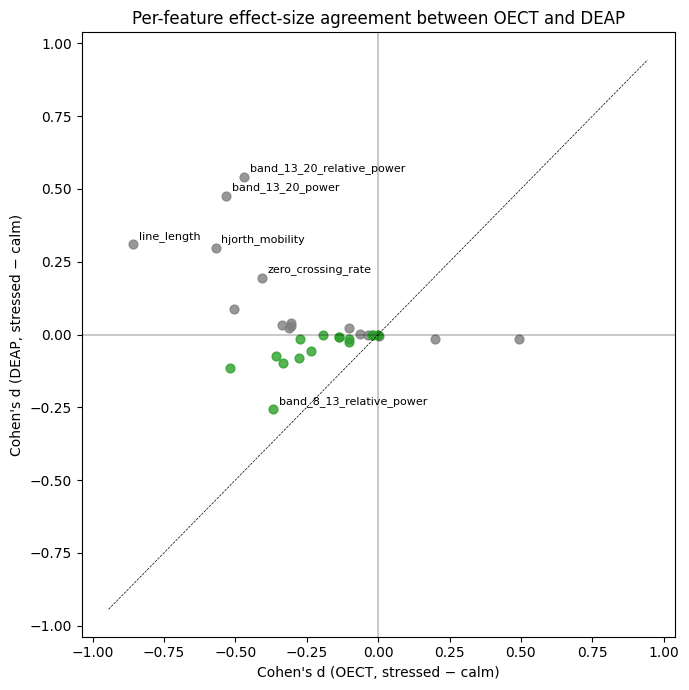

In [13]:
# Scatter: OECT d vs DEAP d
plt.figure(figsize=(7,7))
for _, r in merged.iterrows():
    color = 'tab:green' if r['same_sign'] else 'tab:gray'
    plt.scatter(r['OECT_d'], r['DEAP_d'], color=color, s=40, alpha=0.8)
lim = max(abs(merged['OECT_d']).max(), abs(merged['DEAP_d']).max()) * 1.1
plt.plot([-lim, lim],[-lim, lim], 'k--', lw=0.5)
plt.axhline(0, color='k', lw=0.3); plt.axvline(0, color='k', lw=0.3)
plt.xlabel("Cohen's d (OECT, stressed − calm)")
plt.ylabel("Cohen's d (DEAP, stressed − calm)")
plt.title('Per-feature effect-size agreement between OECT and DEAP')
# annotate strongest features
top_label = merged.assign(abs_min=np.minimum(merged['OECT_d'].abs(), merged['DEAP_d'].abs())) \
                  .sort_values('abs_min', ascending=False).head(6)
for _, r in top_label.iterrows():
    plt.annotate(r['feature'], (r['OECT_d'], r['DEAP_d']), fontsize=8,
                 xytext=(4,4), textcoords='offset points')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'effect_size_scatter_oect_vs_deap.png', dpi=200)
plt.show()

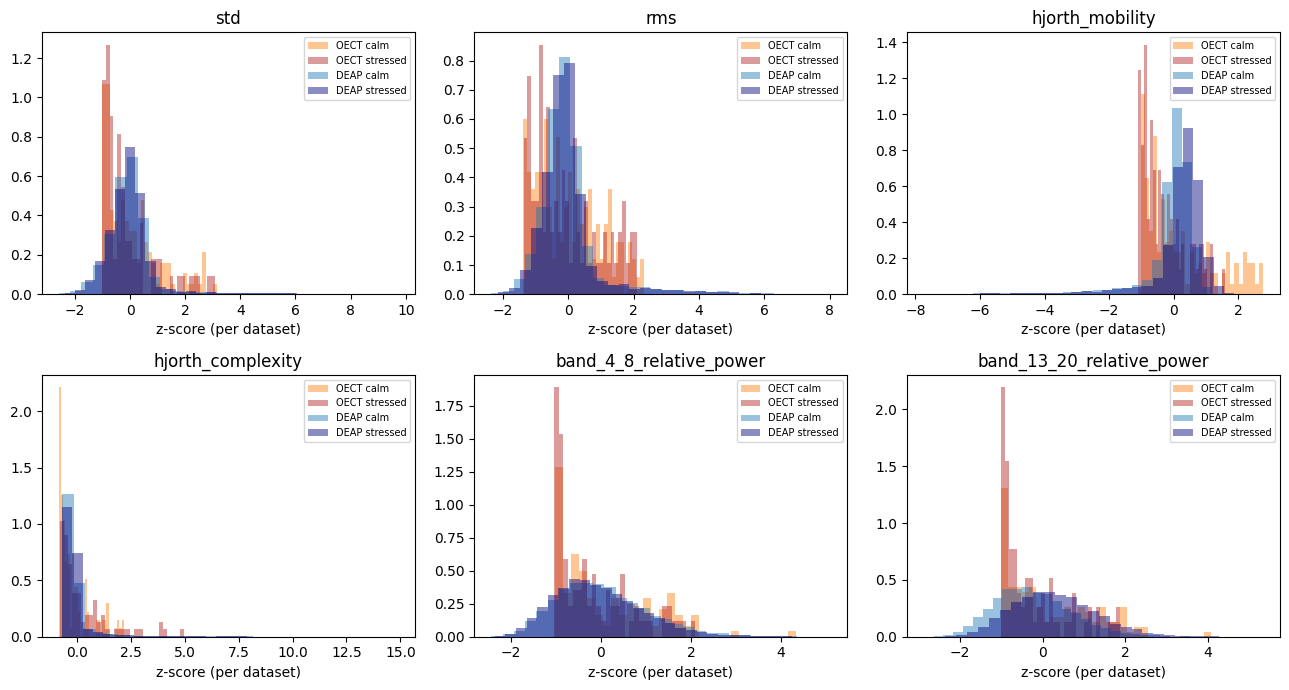

In [14]:
# Distribution overlay for a few features (z-scored within each dataset for visual comparison)
interesting = ['std','rms','hjorth_mobility','hjorth_complexity',
               'band_4_8_relative_power','band_13_20_relative_power']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, interesting):
    if feat not in oect_wf.columns or feat not in deap_wf.columns:
        ax.set_visible(False); continue
    for df, name, colors in [(oect_wf,'OECT',('tab:orange','firebrick')),
                              (deap_wf,'DEAP',('tab:blue','navy'))]:
        c0 = df[df['label_arousal']==0][feat]
        c1 = df[df['label_arousal']==1][feat]
        z0 = (c0 - df[feat].mean()) / (df[feat].std() + 1e-12)
        z1 = (c1 - df[feat].mean()) / (df[feat].std() + 1e-12)
        ax.hist(z0, bins=30, alpha=0.45, label=f'{name} calm',     color=colors[0], density=True)
        ax.hist(z1, bins=30, alpha=0.45, label=f'{name} stressed', color=colors[1], density=True)
    ax.set_title(feat); ax.legend(fontsize=7); ax.set_xlabel('z-score (per dataset)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_distribution_overlay.png', dpi=200)
plt.show()

## 8. Summary table

In [15]:
summary = pd.DataFrame([
    {'dataset':'OECT (file-grouped CV)','signal_type':'PEDOT:PSS drain current','fs_hz':400,
     'channels':1,'n_subjects':int(oect_meta['subject_id'].nunique()),
     'n_recordings_calm':int((oect_meta['condition']=='relaxed').sum()),
     'n_recordings_stressed':int((oect_meta['condition']=='stressed').sum()),
     'n_windows':int(len(oect_wf)),
     'best_model':oect_results_file.iloc[0]['model'],
     'agg_accuracy':float(oect_results_file.iloc[0]['agg_accuracy']),
     'agg_macro_f1':float(oect_results_file.iloc[0]['agg_macro_f1'])},
    {'dataset':'OECT (subject-grouped CV)','signal_type':'PEDOT:PSS drain current','fs_hz':400,
     'channels':1,'n_subjects':int(oect_meta['subject_id'].nunique()),
     'n_recordings_calm':int((oect_meta['condition']=='relaxed').sum()),
     'n_recordings_stressed':int((oect_meta['condition']=='stressed').sum()),
     'n_windows':int(len(oect_wf)),
     'best_model':oect_results_subj.iloc[0]['model'],
     'agg_accuracy':float(oect_results_subj.iloc[0]['agg_accuracy']),
     'agg_macro_f1':float(oect_results_subj.iloc[0]['agg_macro_f1'])},
    {'dataset':'DEAP (subject-grouped CV)','signal_type':'scalp EEG (frontal)','fs_hz':int(DEAP_FS),
     'channels':len(DEAP_FRONTAL_CHANNELS),
     'n_subjects':int(deap_wf['subject_id'].nunique()),
     'n_recordings_calm':int(deap_wf[deap_wf['label_arousal']==0]['trial_id'].nunique()),
     'n_recordings_stressed':int(deap_wf[deap_wf['label_arousal']==1]['trial_id'].nunique()),
     'n_windows':int(len(deap_wf)),
     'best_model':deap_results.iloc[0]['model'],
     'agg_accuracy':float(deap_results.iloc[0]['agg_accuracy']),
     'agg_macro_f1':float(deap_results.iloc[0]['agg_macro_f1'])},
])
summary.to_csv(OUTPUT_DIR / 'dataset_summary.csv', index=False)
print(summary.to_string(index=False))

                  dataset             signal_type  fs_hz  channels  n_subjects  n_recordings_calm  n_recordings_stressed  n_windows          best_model  agg_accuracy  agg_macro_f1
   OECT (file-grouped CV) PEDOT:PSS drain current    400         1           8                 15                      9        216       Random Forest      0.833333      0.822222
OECT (subject-grouped CV) PEDOT:PSS drain current    400         1           8                 15                      9        216       Random Forest      0.833333      0.822222
DEAP (subject-grouped CV)     scalp EEG (frontal)    128         6          10                168                    135      21816 Logistic Regression      0.808581      0.805683
